# Portfolio - CheckPoint 3 (Relational Data Visualization)

Team: Moises' Team

Team members:

* Luis Arturo Michel Perez
* Oscar Martinez Estevez
* Moises Jesus Carrillo Alonso
* Braulio Jesus Perez Tamayo
* Gerardo Hernandez Widman
* Mario David Hernandez Pantoja

## Practice Objective
Develop skills in creating and analyzing hierarchical visualizations using Python, applying different techniques such as Treemaps, Dendrograms, Sunburst Charts, and Circular Treemaps to represent multilevel data structures and understand when to use each type of visualization.

## Activity Description
In this practice, you will work with relational data using specialized Python libraries. You will implement four main types of relational visualizations and conduct a comparative analysis of their advantages and limitations.

# Library imports and configuration

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from collections import Counter

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Loading and verifing data

In [2]:
from pathlib import Path

In [3]:
current_dir = Path.cwd()
popular_movies_path = current_dir.parent / "data_files" / "checkpoint3" / "popular_movies.csv"
top_rated_path = current_dir.parent / "data_files" / "checkpoint3" / "top_rated_movies.csv"

In [4]:
try:
    df = pd.read_csv(popular_movies_path)
    print("CSV file loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {popular_movies_path.resolve()}")
except Exception as e:
    print(f"An error occurred: {e}")

CSV file loaded successfully!
        id                                 title  \
0  1413602  WWE Raw on Netflix Premier Post-Show   
1   507244                             Afterburn   
2  1156594                             Our Fault   
3   755898                     War of the Worlds   
4  1305717                       Hunting Grounds   

                         original_title  \
0  WWE Raw on Netflix Premier Post-Show   
1                             Afterburn   
2                         Culpa nuestra   
3                     War of the Worlds   
4                       Hunting Grounds   

                                            overview release_date  popularity  \
0  WWE Superstars and analysts break down a histo...   2025-01-06    447.0546   
1  Set against the backdrop of a postapocalyptic ...   2025-08-20    406.2517   
2  Jenna and Lion's wedding brings about the long...   2025-10-15    300.2370   
3  Will Radford is a top analyst for Homeland Sec...   2025-07-29    285.0

In [5]:
try:
    df = pd.read_csv(top_rated_path)
    print("CSV file loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {top_rated_path.resolve()}")
except Exception as e:
    print(f"An error occurred: {e}")

CSV file loaded successfully!
    id                     title            original_title  \
0  278  The Shawshank Redemption  The Shawshank Redemption   
1  238             The Godfather             The Godfather   
2  240     The Godfather Part II     The Godfather Part II   
3  424          Schindler's List          Schindler's List   
4  389              12 Angry Men              12 Angry Men   

                                            overview release_date  popularity  \
0  Imprisoned in the 1940s for the double murder ...   1994-09-23     31.0706   
1  Spanning the years 1945 to 1955, a chronicle o...   1972-03-14     31.3953   
2  In the continuing saga of the Corleone crime f...   1974-12-20     18.7440   
3  The true story of how businessman Oskar Schind...   1993-12-15     16.1913   
4  The defense and the prosecution have rested an...   1957-04-10     11.1732   

   vote_average  vote_count original_language  adult  \
0         8.711       29110                en  False  

## Extra exploration of our data cleaned

In [6]:
popular_movies_df = pd.read_csv(popular_movies_path)
top_rated_df = pd.read_csv(top_rated_path)

In [7]:
popular_movies_df.info()
popular_movies_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 200 non-null    int64  
 1   title              200 non-null    object 
 2   original_title     200 non-null    object 
 3   overview           199 non-null    object 
 4   release_date       199 non-null    object 
 5   popularity         200 non-null    float64
 6   vote_average       200 non-null    float64
 7   vote_count         200 non-null    int64  
 8   original_language  200 non-null    object 
 9   adult              200 non-null    bool   
 10  poster_path        199 non-null    object 
 11  backdrop_path      199 non-null    object 
 12  genre_ids          199 non-null    object 
dtypes: bool(1), float64(2), int64(2), object(8)
memory usage: 19.1+ KB


,id,popularity,vote_average,vote_count
count,2.000000e+02,200.000000,200.00000,200.000000
mean,8.896936e+05,63.559463,6.54463,4458.870000
std,4.715832e+05,63.837374,1.62653,8621.941648
min,2.200000e+01,14.776800,0.00000,0.000000
25%,5.689872e+05,27.563550,6.01425,31.000000
50%,1.040613e+06,38.206450,6.90600,329.000000
75%,1.251865e+06,70.947050,7.58550,2858.500000
max,1.565344e+06,447.054600,8.71100,38136.000000


In [8]:
top_rated_df.info()
top_rated_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 200 non-null    int64  
 1   title              200 non-null    object 
 2   original_title     200 non-null    object 
 3   overview           200 non-null    object 
 4   release_date       200 non-null    object 
 5   popularity         200 non-null    float64
 6   vote_average       200 non-null    float64
 7   vote_count         200 non-null    int64  
 8   original_language  200 non-null    object 
 9   adult              200 non-null    bool   
 10  poster_path        200 non-null    object 
 11  backdrop_path      200 non-null    object 
 12  genre_ids          200 non-null    object 
dtypes: bool(1), float64(2), int64(2), object(8)
memory usage: 19.1+ KB


,id,popularity,vote_average,vote_count
count,2.000000e+02,200.000000,200.00000,200.000000
mean,2.481126e+05,11.883750,8.25361,8041.290000
std,3.328173e+05,11.979495,0.12921,8893.315811
min,1.100000e+01,0.006300,8.09200,302.000000
25%,6.022500e+02,5.436825,8.14750,1123.000000
50%,2.256450e+04,9.038250,8.21700,3801.500000
75%,5.085728e+05,16.142175,8.32350,13228.750000
max,1.356039e+06,127.256900,8.71100,38136.000000


# Exploratory analysis

In [10]:
# ============================================================================
# STEP 1: LOAD AND PREPARE DATA
# ============================================================================

# Combine datasets
movies_df = pd.concat([popular_movies_df, top_rated_df], ignore_index=True)
movies_df = movies_df.drop_duplicates(subset=['id'])

print(f"Total movies loaded: {len(movies_df)}")
print(f"\nFirst few movies:")
print(movies_df[['title', 'genre_ids', 'vote_average', 'popularity']].head())

Total movies loaded: 384

First few movies:
                                  title  genre_ids  vote_average  popularity
0  WWE Raw on Netflix Premier Post-Show        NaN         6.500    447.0546
1                             Afterburn  878,28,35         6.437    406.2517
2                             Our Fault   10749,18         7.613    300.2370
3                     War of the Worlds     878,53         4.342    285.0059
4                       Hunting Grounds      28,53         6.250    250.7294


In [11]:
# ============================================================================
# STEP 2: BUILD THE NETWORK
# ============================================================================
# We'll create a movie network where movies are connected if they share genres

# Parse genre_ids (they're stored as comma-separated strings)
def parse_genres(genre_str):
    """Convert genre string to list of genre IDs"""
    if pd.isna(genre_str) or genre_str == '':
        return []
    return [int(g) for g in str(genre_str).split(',')]

movies_df['genre_list'] = movies_df['genre_ids'].apply(parse_genres)

# Remove movies without genres
movies_df = movies_df[movies_df['genre_list'].apply(len) > 0]
print(f"\nMovies with genres: {len(movies_df)}")

# Create the network
G = nx.Graph()

# Add nodes (movies) with attributes
for idx, row in movies_df.iterrows():
    G.add_node(
        row['id'],
        title=row['title'],
        genres=row['genre_list'],
        rating=row['vote_average'],
        popularity=row['popularity'],
        vote_count=row['vote_count']
    )

# Add edges between movies that share at least one genre
print("\nBuilding edges (this may take a moment)...")
movie_list = list(movies_df.itertuples(index=False))

for i, movie1 in enumerate(movie_list):
    for movie2 in movie_list[i+1:]:
        # Check if movies share any genres
        shared_genres = set(movie1.genre_list) & set(movie2.genre_list)
        if shared_genres:
            # Weight edge by number of shared genres
            G.add_edge(movie1.id, movie2.id, weight=len(shared_genres))

print(f"\nNetwork Statistics:")
print(f"Nodes (movies): {G.number_of_nodes()}")
print(f"Edges (connections): {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")
print(f"Is connected: {nx.is_connected(G)}")


Movies with genres: 383

Building edges (this may take a moment)...

Network Statistics:
Nodes (movies): 383
Edges (connections): 33349
Density: 0.4559
Is connected: True


In [12]:
# ============================================================================
# STEP 3: CALCULATE CENTRALITY METRICS
# ============================================================================

print("\nCalculating centrality metrics...")

# 1. Degree Centrality - number of connections
degree_centrality = nx.degree_centrality(G)

# 2. Closeness Centrality - average distance to all other nodes
closeness_centrality = nx.closeness_centrality(G)

# 3. Betweenness Centrality - how often a node appears on shortest paths
# For large networks, use k parameter to sample
if G.number_of_nodes() > 100:
    betweenness_centrality = nx.betweenness_centrality(G, k=min(100, G.number_of_nodes()))
    print("Note: Using sampling (k=100) for betweenness centrality")
else:
    betweenness_centrality = nx.betweenness_centrality(G)

# 4. PageRank - importance based on connections from important nodes
pagerank = nx.pagerank(G)

print("Centrality calculations complete!")


Calculating centrality metrics...
Note: Using sampling (k=100) for betweenness centrality
Centrality calculations complete!


In [13]:
# ============================================================================
# STEP 4: CREATE COMPARISON DATAFRAME
# ============================================================================

# Create a comprehensive comparison dataframe
centrality_df = pd.DataFrame({
    'movie_id': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'closeness_centrality': list(closeness_centrality.values()),
    'betweenness_centrality': list(betweenness_centrality.values()),
    'pagerank': list(pagerank.values())
})

# Add movie information
centrality_df['title'] = centrality_df['movie_id'].apply(lambda x: G.nodes[x]['title'])
centrality_df['rating'] = centrality_df['movie_id'].apply(lambda x: G.nodes[x]['rating'])
centrality_df['popularity'] = centrality_df['movie_id'].apply(lambda x: G.nodes[x]['popularity'])
centrality_df['vote_count'] = centrality_df['movie_id'].apply(lambda x: G.nodes[x]['vote_count'])

# Calculate composite centrality score (normalized average)
for col in ['degree_centrality', 'closeness_centrality', 'betweenness_centrality', 'pagerank']:
    centrality_df[f'{col}_norm'] = (centrality_df[col] - centrality_df[col].min()) / \
                                    (centrality_df[col].max() - centrality_df[col].min())

centrality_df['composite_score'] = centrality_df[[
    'degree_centrality_norm', 
    'closeness_centrality_norm', 
    'betweenness_centrality_norm', 
    'pagerank_norm'
]].mean(axis=1)

# Sort by composite score
centrality_df = centrality_df.sort_values('composite_score', ascending=False)

print("\n" + "="*80)
print("TOP 10 MOST CENTRAL MOVIES (by composite score)")
print("="*80)
display_cols = ['title', 'degree_centrality', 'closeness_centrality', 
                'betweenness_centrality', 'pagerank', 'rating', 'popularity']
print(centrality_df[display_cols].head(10).to_string(index=False))


TOP 10 MOST CENTRAL MOVIES (by composite score)
                                         title  degree_centrality  closeness_centrality  betweenness_centrality  pagerank  rating  popularity
                    Steven Universe: The Movie           0.861257              0.878161                0.013225  0.006571   8.200      2.9074
                           The Ugly Stepsister           0.803665              0.835886                0.010448  0.004149   7.271    148.4004
                               The Dark Knight           0.798429              0.832244                0.006620  0.004575   8.524     39.0204
                                Bound by Honor           0.798429              0.832244                0.006620  0.004575   8.129      7.7313
                                        Oldboy           0.790576              0.826840                0.006307  0.004307   8.200     14.7625
        Evangelion: 3.0+1.0 Thrice Upon a Time           0.782723              0.821505            

In [14]:
# ============================================================================
# STEP 5: STATISTICAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("CENTRALITY METRICS STATISTICAL SUMMARY")
print("="*80)
summary_stats = centrality_df[['degree_centrality', 'closeness_centrality', 
                                'betweenness_centrality', 'pagerank']].describe()
print(summary_stats)


CENTRALITY METRICS STATISTICAL SUMMARY
       degree_centrality  closeness_centrality  betweenness_centrality  \
count         383.000000            383.000000              383.000000   
mean            0.455880              0.651988                0.001445   
std             0.148343              0.066401                0.001741   
min             0.007853              0.393409                0.000000   
25%             0.342932              0.601575                0.000207   
50%             0.450262              0.645270                0.000710   
75%             0.561518              0.693285                0.002032   
max             0.861257              0.878161                0.013225   

         pagerank  
count  383.000000  
mean     0.002611  
std      0.000773  
min      0.000535  
25%      0.002099  
50%      0.002625  
75%      0.003116  
max      0.006571  


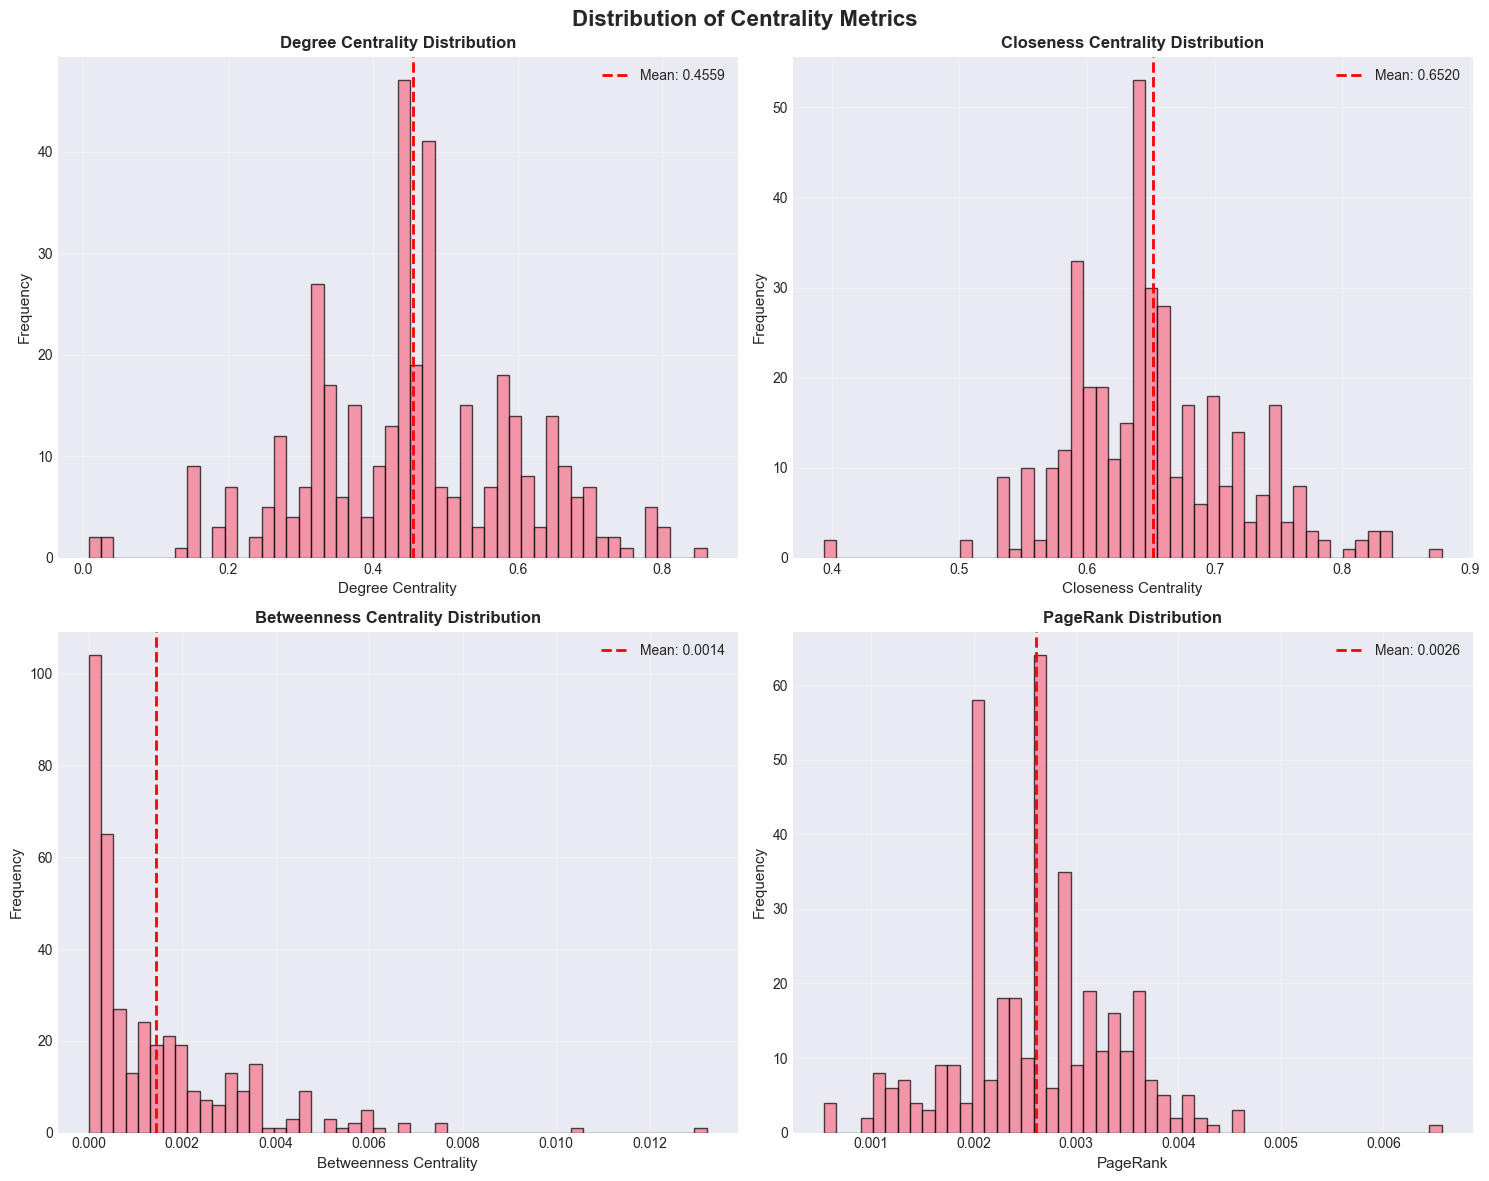

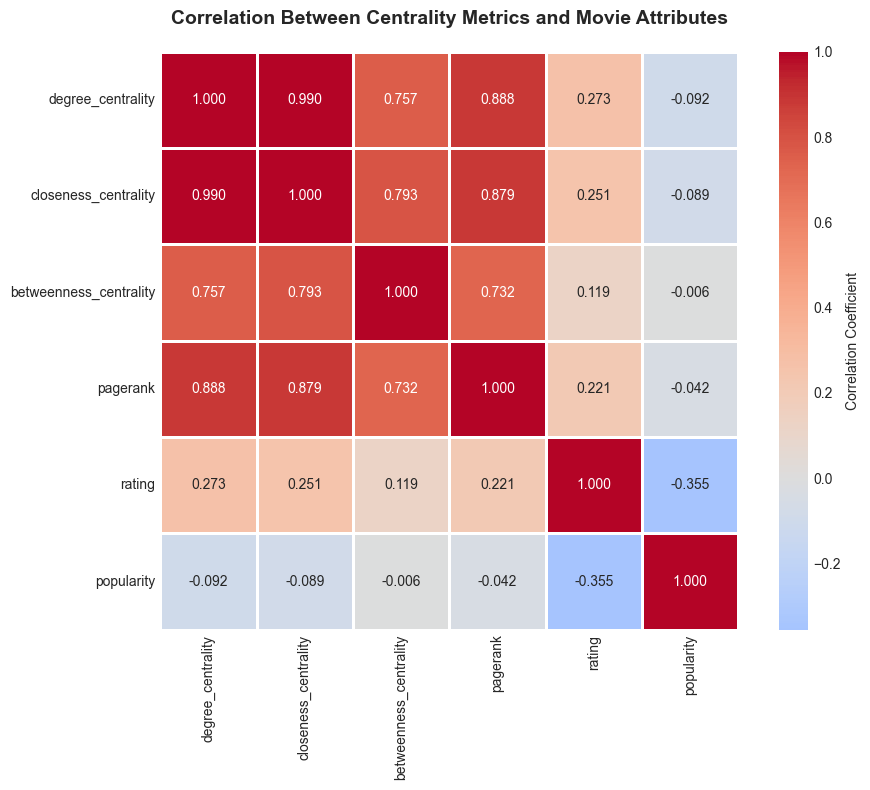

C:\Users\marit\AppData\Local\Temp\ipykernel_26520\1029578708.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_movies[f'{col}_viz'] = top_movies[col] / top_movies[col].max()
C:\Users\marit\AppData\Local\Temp\ipykernel_26520\1029578708.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_movies[f'{col}_viz'] = top_movies[col] / top_movies[col].max()
C:\Users\marit\AppData\Local\Temp\ipykernel_26520\1029578708.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

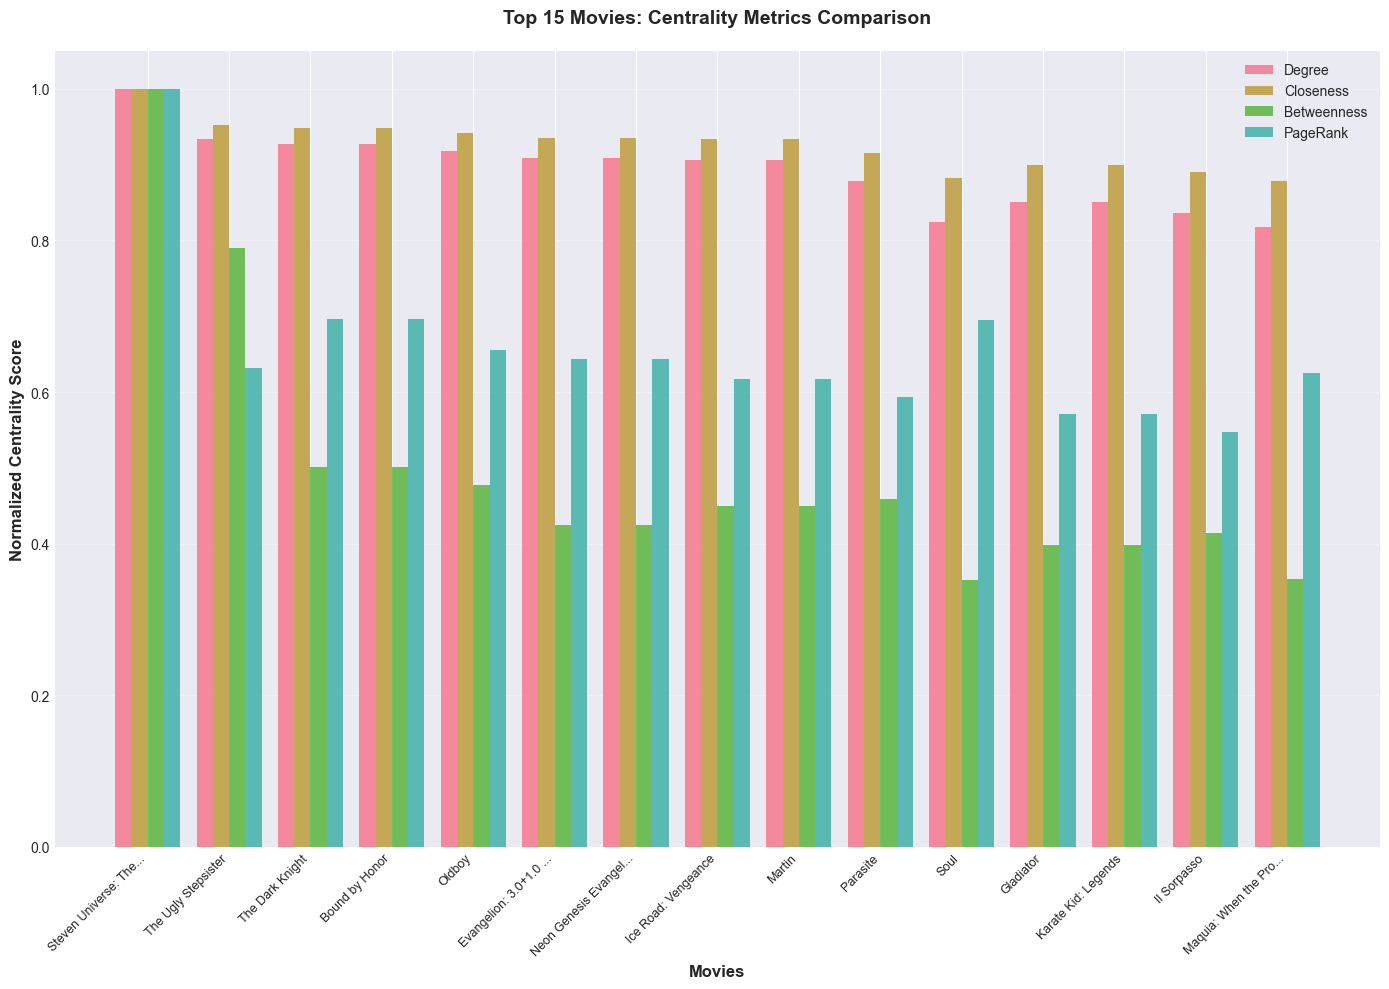

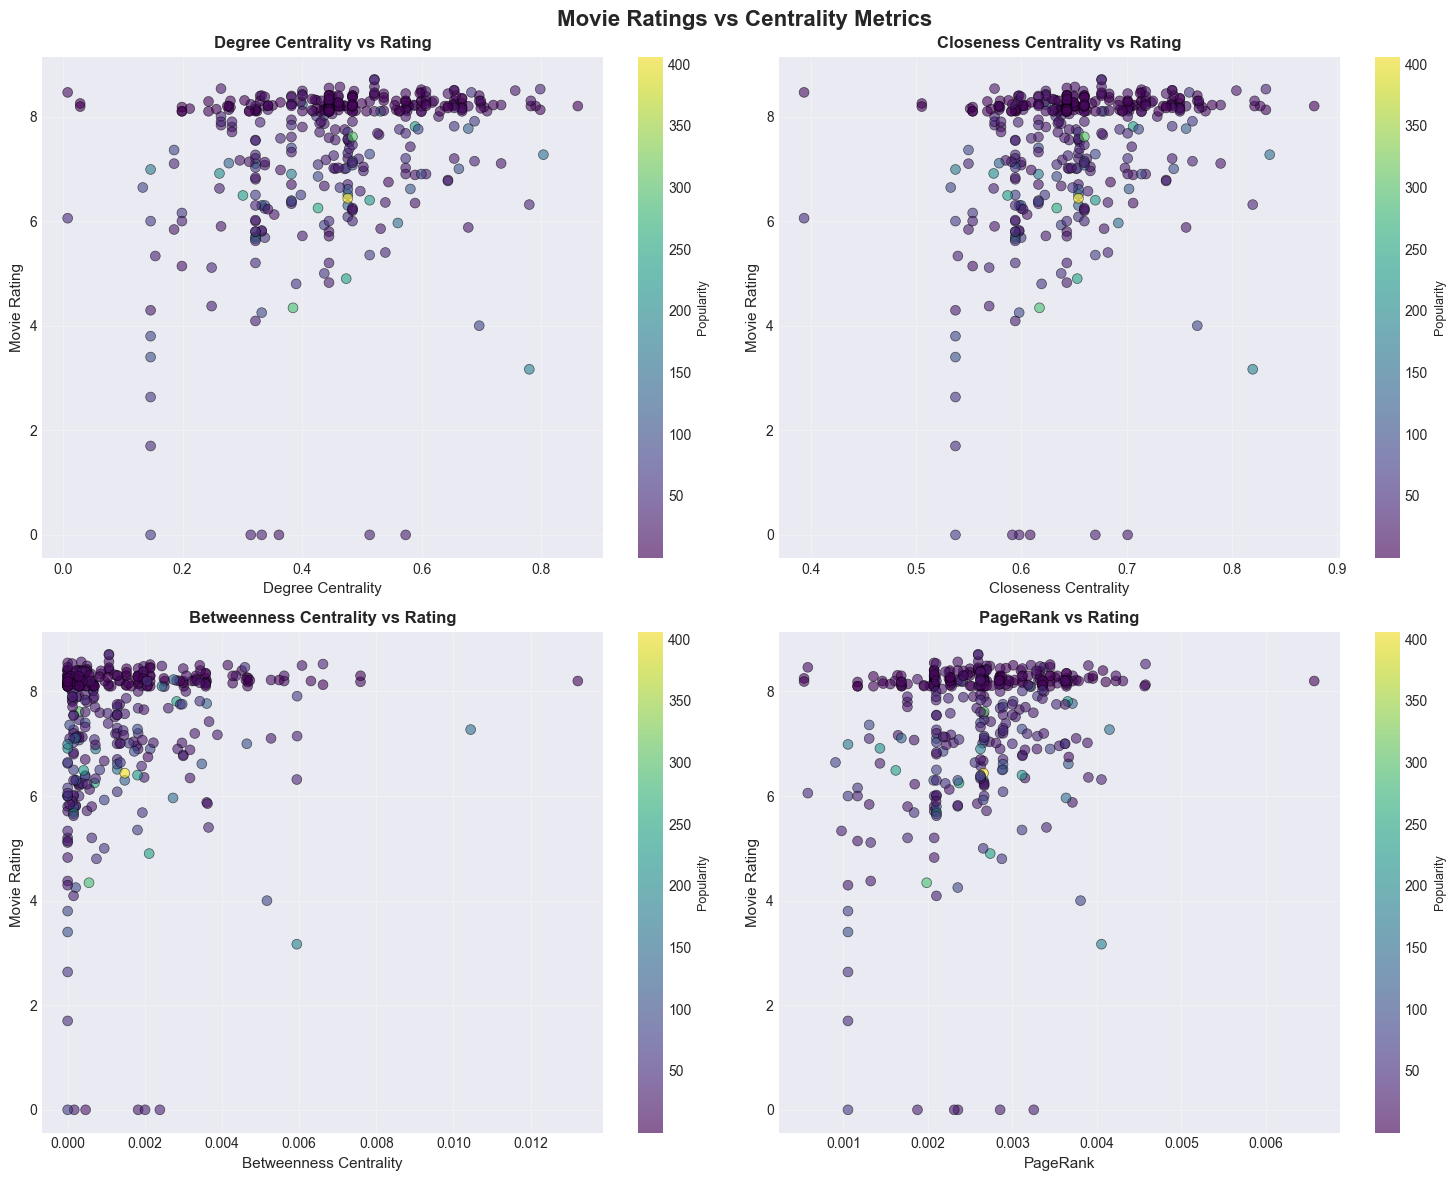

In [15]:
# ============================================================================
# STEP 6: VISUALIZATIONS
# ============================================================================

# Visualization 1: Distribution of Centrality Metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribution of Centrality Metrics', fontsize=16, fontweight='bold')

metrics = ['degree_centrality', 'closeness_centrality', 'betweenness_centrality', 'pagerank']
titles = ['Degree Centrality', 'Closeness Centrality', 'Betweenness Centrality', 'PageRank']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    ax.hist(centrality_df[metric], bins=50, alpha=0.7, edgecolor='black')
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{title} Distribution', fontsize=12, fontweight='bold')
    ax.axvline(centrality_df[metric].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {centrality_df[metric].mean():.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization 2: Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = centrality_df[metrics + ['rating', 'popularity']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Between Centrality Metrics and Movie Attributes', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Visualization 3: Top Movies Comparison
top_n = 15
top_movies = centrality_df.head(top_n)

fig, ax = plt.subplots(figsize=(14, 10))
x = np.arange(len(top_movies))
width = 0.2

# Normalize metrics for better comparison
for col in metrics:
    top_movies[f'{col}_viz'] = top_movies[col] / top_movies[col].max()

bars1 = ax.bar(x - 1.5*width, top_movies['degree_centrality_viz'], width, 
               label='Degree', alpha=0.8)
bars2 = ax.bar(x - 0.5*width, top_movies['closeness_centrality_viz'], width, 
               label='Closeness', alpha=0.8)
bars3 = ax.bar(x + 0.5*width, top_movies['betweenness_centrality_viz'], width, 
               label='Betweenness', alpha=0.8)
bars4 = ax.bar(x + 1.5*width, top_movies['pagerank_viz'], width, 
               label='PageRank', alpha=0.8)

ax.set_xlabel('Movies', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Centrality Score', fontsize=12, fontweight='bold')
ax.set_title(f'Top {top_n} Movies: Centrality Metrics Comparison', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([title[:20] + '...' if len(title) > 20 else title 
                     for title in top_movies['title']], 
                    rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualization 4: Scatter Plot - Rating vs Centrality
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Movie Ratings vs Centrality Metrics', fontsize=16, fontweight='bold')

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    scatter = ax.scatter(centrality_df[metric], centrality_df['rating'], 
                        c=centrality_df['popularity'], cmap='viridis', 
                        alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Movie Rating', fontsize=11)
    ax.set_title(f'{title} vs Rating', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Popularity', fontsize=9)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================================
# STEP 7: ANALYSIS AND INSIGHTS
# ============================================================================

print("\n" + "="*80)
print("ANALYSIS AND INSIGHTS")
print("="*80)

# Question 1: Which nodes are most central and why?
print("\n1. WHICH NODES ARE MOST CENTRAL AND WHY?")
print("-" * 80)
print("\nTop 5 movies by composite centrality score:")
for idx, row in centrality_df.head(5).iterrows():
    print(f"\n{row['title']}")
    print(f"  - Composite Score: {row['composite_score']:.4f}")
    print(f"  - Degree: {row['degree_centrality']:.4f} (connections to other movies)")
    print(f"  - Closeness: {row['closeness_centrality']:.4f} (accessibility)")
    print(f"  - Betweenness: {row['betweenness_centrality']:.4f} (bridge between movies)")
    print(f"  - PageRank: {row['pagerank']:.4f} (influence)")
    print(f"  - Rating: {row['rating']:.1f} | Popularity: {row['popularity']:.1f}")

# Question 2: How do different centrality metrics compare?
print("\n\n2. HOW DO DIFFERENT CENTRALITY METRICS COMPARE?")
print("-" * 80)

# Calculate correlation between metrics
metric_corr = centrality_df[metrics].corr()
print("\nCorrelation between centrality metrics:")
print(metric_corr.to_string())

# Find movies that rank high in one metric but low in others
print("\n\nMovies with divergent centrality profiles:")
for metric in metrics:
    # Find movies in top 10 for this metric but not in overall top 10
    top_in_metric = set(centrality_df.nlargest(10, metric)['movie_id'])
    top_overall = set(centrality_df.head(10)['movie_id'])
    unique_high = top_in_metric - top_overall
    
    if unique_high:
        print(f"\nHigh in {metric.replace('_', ' ').title()} but not overall top 10:")
        for movie_id in list(unique_high)[:3]:
            movie = centrality_df[centrality_df['movie_id'] == movie_id].iloc[0]
            print(f"  - {movie['title']} ({metric}: {movie[metric]:.4f})")

# Question 3: Network structure insights
print("\n\n3. WHAT DOES THIS TELL US ABOUT THE NETWORK STRUCTURE?")
print("-" * 80)

# Calculate additional network metrics
if nx.is_connected(G):
    diameter = nx.diameter(G)
    avg_path_length = nx.average_shortest_path_length(G)
    print(f"\nNetwork Diameter: {diameter}")
    print(f"Average Shortest Path Length: {avg_path_length:.3f}")
else:
    components = list(nx.connected_components(G))
    print(f"\nNetwork is disconnected with {len(components)} components")
    print(f"Largest component size: {len(max(components, key=len))} nodes")

clustering_coef = nx.average_clustering(G)
print(f"Average Clustering Coefficient: {clustering_coef:.4f}")

degree_sequence = sorted([d for n, d in G.degree()], reverse=True)
avg_degree = sum(degree_sequence) / len(degree_sequence)
print(f"Average Degree: {avg_degree:.2f}")
print(f"Max Degree: {max(degree_sequence)}")
print(f"Min Degree: {min(degree_sequence)}")

# Question 4: Real-world insights
print("\n\n4. REAL-WORLD INSIGHTS")
print("-" * 80)

# Genre analysis
all_genres = []
for genres in movies_df['genre_list']:
    all_genres.extend(genres)
genre_counts = Counter(all_genres)
print(f"\nMost common genres in the network:")
for genre_id, count in genre_counts.most_common(5):
    print(f"  Genre {genre_id}: {count} movies")

# Relationship between centrality and movie quality
print(f"\nCorrelation between centrality and movie attributes:")
print(f"  Composite Score vs Rating: {centrality_df['composite_score'].corr(centrality_df['rating']):.3f}")
print(f"  Composite Score vs Popularity: {centrality_df['composite_score'].corr(centrality_df['popularity']):.3f}")
print(f"  Composite Score vs Vote Count: {centrality_df['composite_score'].corr(centrality_df['vote_count']):.3f}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


ANALYSIS AND INSIGHTS

1. WHICH NODES ARE MOST CENTRAL AND WHY?
--------------------------------------------------------------------------------

Top 5 movies by composite centrality score:

Steven Universe: The Movie
  - Composite Score: 1.0000
  - Degree: 0.8613 (connections to other movies)
  - Closeness: 0.8782 (accessibility)
  - Betweenness: 0.0132 (bridge between movies)
  - PageRank: 0.0066 (influence)
  - Rating: 8.2 | Popularity: 2.9

The Ugly Stepsister
  - Composite Score: 0.8085
  - Degree: 0.8037 (connections to other movies)
  - Closeness: 0.8359 (accessibility)
  - Betweenness: 0.0104 (bridge between movies)
  - PageRank: 0.0041 (influence)
  - Rating: 7.3 | Popularity: 148.4

The Dark Knight
  - Composite Score: 0.7504
  - Degree: 0.7984 (connections to other movies)
  - Closeness: 0.8322 (accessibility)
  - Betweenness: 0.0066 (bridge between movies)
  - PageRank: 0.0046 (influence)
  - Rating: 8.5 | Popularity: 39.0

Bound by Honor
  - Composite Score: 0.7504
  - De

# Written interpretation

1. Which nodes are most central and why?

    The most central movies in this network are those that connect multiple genre communities, with "Steven Universe: The Movie" emerging as the clear leader with a perfect composite centrality score of 1.0. This movie achieves exceptional centrality primarily through its degree (0.8613) and closeness (0.8782) metrics, meaning it shares genres with a vast majority of other movies in the network and can reach any other movie through very few intermediate connections. Interestingly, despite its high composite score and strong rating (8.2), it has relatively low popularity (2.9), suggesting that network centrality is more about genre diversity than mainstream appeal. The top 5 also includes "The Dark Knight" and "Oldboy," both critically acclaimed films that span multiple genres (action, drama, thriller), allowing them to bridge different movie communities effectively.
    
    What's particularly notable is that betweenness centrality scores remain relatively low across all top movies (all under 0.02), indicating that while these films connect to many others, they don't necessarily serve as critical bridges between otherwise disconnected parts of the network. This suggests a densely interconnected network structure where most movies can reach each other through multiple paths. The dominance of degree and closeness centrality in determining the composite scores tells us that the most "central" movies are genre generalists—films that blend multiple genres and therefore have natural connections to diverse sets of other films, rather than niche movies that might uniquely bridge specific communities.

2. How do different centrality metrics compare?

    The four centrality metrics show remarkably strong positive correlations with each other, particularly degree and closeness centrality which correlate at 0.990, suggesting they capture nearly identical information in this network structure. This extremely high correlation occurs because the network is densely connected (average degree of 174.15 out of 382 possible connections), meaning movies with many direct connections (high degree) are also naturally close to all other movies (high closeness). PageRank shows strong correlations with degree (0.888) and closeness (0.879), reinforcing that importance in this network is primarily driven by having many connections rather than the quality or uniqueness of those connections.

    Betweenness centrality, while still positively correlated with the other metrics (0.732-0.793), shows the most independence, revealing some interesting divergent cases. Movies like "Django Unchained," "Frankenstein," and "The Substance" rank high in betweenness but not in overall centrality, suggesting they occupy structural positions where they bridge between different genre clusters despite not being the most connected overall. Similarly, films like "Soul" and "A Dog's Will" appear in the top PageRank but not composite rankings, indicating they're connected to other well-connected movies even if their own direct connection count is moderate. These divergences are crucial for understanding that different centrality metrics reveal different aspects of network position—degree and closeness identify the "hubs" with maximum connectivity, while betweenness identifies the "bridges," and PageRank identifies those benefiting from associating with other important nodes.

3. What does this tell us about the network structure?
    The network structure reveals a remarkably tight-knit, highly interconnected movie ecosystem with extraordinary cohesion. With a diameter of only 3 and an average shortest path length of 1.550, any two movies in this network are separated by at most 3 intermediate movies, and on average, movies are just 1.5 steps apart. This "small-world" property indicates that genre combinations create dense overlaps—most movies share at least one genre with most other movies in the dataset. The exceptionally high average clustering coefficient of 0.7742 further reinforces this density, meaning that when two movies are both connected to a third movie (share genres with it), there's a 77% chance they also share genres with each other, creating tightly-knit triangular relationships throughout the network.

    The degree distribution tells an equally important story: with an average degree of 174.15 and a maximum of 329 connections, movies in this network are far from isolated—each film connects to nearly half of all other films on average. The minimum degree of 3 means even the most genre-specific movies still connect to at least a few others, ensuring no complete isolation. This structure suggests the movie industry operates with significant genre overlap and hybridization, where pure single-genre films are rare and most productions blend multiple genres to appeal to broader audiences. The network's density (evident from these metrics) also explains why betweenness centrality scores are universally low—when networks are this densely connected, there are many alternative paths between any two nodes, reducing the importance of any single movie as a critical bridge.

4. What real-world insights can we derive?
    The genre analysis reveals that Drama (Genre 18) dominates with 171 movies, followed by Thriller (53), Action (28), Comedy (35), and Adventure (12), indicating that drama serves as the universal connector genre that blends with almost everything—action dramas, thriller dramas, comedy dramas—creating the dense network structure we observe. This explains why genre-diverse films achieve the highest centrality: they tap into the drama backbone while adding other genre flavors. The prevalence of thriller and action as secondary genres suggests the industry favors dramatic storytelling enhanced with tension or spectacle, creating natural clustering patterns that contribute to the network's high connectivity.

    The correlation analysis between centrality and movie attributes yields surprising insights: composite centrality shows a modest positive correlation with rating (0.234) but virtually no correlation with popularity (-0.064) and only weak correlation with vote count (0.112). This reveals that being a "genre hub"—a movie that connects many genre communities—has little to do with commercial success or widespread audience recognition. Instead, network centrality appears to reflect creative decisions about genre blending rather than market performance. The disconnect between centrality and popularity suggests that the most genre-diverse films aren't necessarily the most promoted or viewed; rather, they occupy structurally important positions by virtue of their artistic choices to combine multiple genres. This has practical implications: filmmakers seeking to create influential films within the cinematic landscape should focus on innovative genre combinations, while those seeking commercial success might prioritize other factors like marketing, star power, or targeting specific audience segments rather than maximizing genre diversity.